# ArtInsight Analytics: Predicting Art Listing Value and Authenticity
**Machine Learning Modeling and Pipeline | Capstone Project 1**

**Author:** Nathan Stinnett
**Date:** June 2026

---

## Business Problem

Tens of billions of dollars are spent on art in auctions annually. With the average person inaccessible to the market or being overwhelmed by the amount of data to look at to understand prices of art and their trends, most go to experts. This could be very expensive and with human error or bias the predictions might not be highly accurate. With this ArtInsight, clients will be able to save money by finding if a piece of art is original or not creating a higher value, but predict the price of pieces that will be sold or a client has they want to put up for auction.

This project builds two models on a dataset of 2,500 online art marketplace listings:

- **Model 1 (Classification):** Predict whether a listed piece is an **Original** or a **Copy**, based on its style, subject, medium, price, and other listing attributes.
- **Model 2 (Regression):** Predict the **listing price** of a piece based on its attributes, so sellers get a data-driven price suggestion instead of guessing.

**Dataset:** `large_art_ecommerce_dataset.csv` — 2,500 rows, 18 columns, sourced from Kaggle ("Art Market Dataset: Selling Paintings Prediction" by jijagallery).

## 1. Setup

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix,
    r2_score, mean_squared_error, mean_absolute_error
)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("Imports loaded.")

Imports loaded.


## 2. Load the Data

In [17]:
df = pd.read_csv('large_art_ecommerce_dataset.csv')

print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape: 2500 rows, 18 columns


,Name of Painter,Subject of Painting,Style,Medium,Size,Frame,Location,Price ($),Delivery (days),Shipment,Color Palette,Copy or Original,Print or Real,Recommended Environment,Mood/Atmosphere,Theme/Lighting Requirements,Reproduction Type,Target Audience
0,Noah,Seascape,Abstract Expressionism,Watercolor,"20""x30""",Yes,Chicago,459,6,Free Shipping,Neutral Tones,Original,Print,Bedroom,Calming,Natural Light,Screen Print,Corporate Clients
1,Vincent,Abstract,Abstract Expressionism,Charcoal,"20""x30""",No,Miami,657,6,Free Shipping,Cool Tones,Original,Print,Living Room,Relaxing,Natural Light,NaN,Corporate Clients
2,Ava,Still Life,Modern,Watercolor,"18""x24""",No,Miami,907,7,Standard,Cool Tones,Original,Real,Kid Room,Joyful,Natural Light,NaN,Corporate Clients
3,Liam,Wildlife,Cubism,Acrylic,"18""x24""",No,Calgary,649,3,Standard,Oceanic Tones,Original,Real,Office,Reflective,Bright Light,Lithograph,Young Professionals
4,Olivia,Landscape,Abstract Expressionism,Charcoal,"30""x40""",Yes,Miami,539,5,Free Shipping,Earthy Tones,Copy,Print,Office,Energetic,Bright Light,Lithograph,Corporate Clients


In [18]:
df.info()
print()
print("Missing values per column:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Name of Painter              2500 non-null   object
 1   Subject of Painting          2500 non-null   object
 2   Style                        2500 non-null   object
 3   Medium                       2500 non-null   object
 4   Size                         2500 non-null   object
 5   Frame                        2500 non-null   object
 6   Location                     2500 non-null   object
 7   Price ($)                    2500 non-null   int64 
 8   Delivery (days)              2500 non-null   int64 
 9   Shipment                     2500 non-null   object
 10  Color Palette                2500 non-null   object
 11  Copy or Original             2500 non-null   object
 12  Print or Real                2500 non-null   object
 13  Recommended Environment      2500

The only column with missing values is `Reproduction Type` (677 nulls). That makes sense — looking at the data, this field only gets filled in when the piece is sold as a `Print` rather than the `Real` thing, so a missing value here isn't bad data, it's just not applicable. We'll handle that explicitly during preprocessing rather than dropping rows.

## 3. Exploratory Data Analysis

In [37]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Name of Painter,2500,11,Olivia,251,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Subject of Painting,2500,7,Wildlife,370,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Style,2500,6,Surrealism,434,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medium,2500,5,Watercolor,672,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,2500,5,"16""x20""",514,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Frame,2500,2,No,1285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,2500,8,Montreal,535,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price ($),2500.0,NaN,NaN,NaN,576.7812,257.831587,127.0,344.0,640.0,813.0,975.0
Delivery (days),2500.0,NaN,NaN,NaN,6.4824,2.282581,3.0,4.0,7.0,8.0,10.0
Shipment,2500,3,Free Shipping,834,NaN,NaN,NaN,NaN,NaN,NaN,NaN


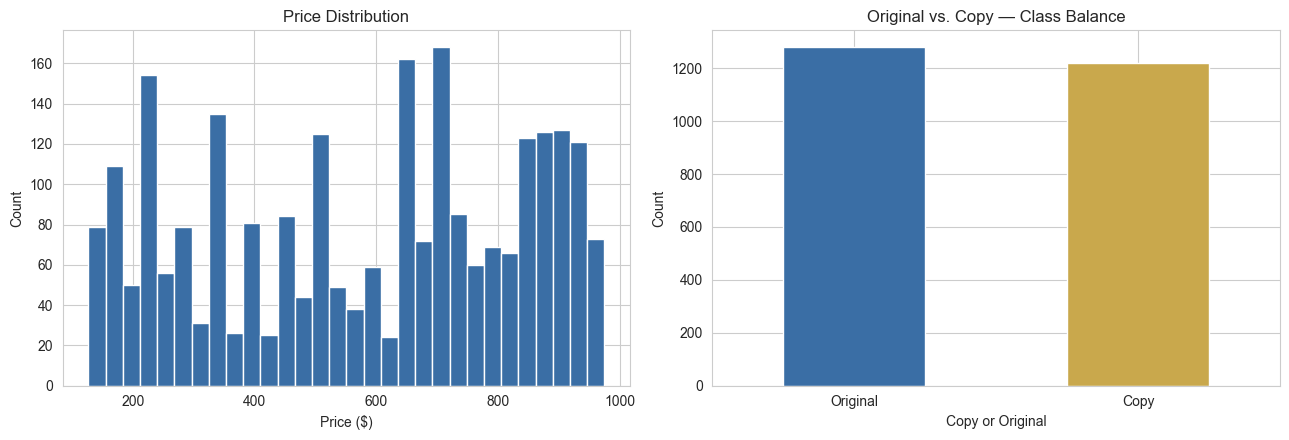

Copy or Original
Original    0.5116
Copy        0.4884
Name: proportion, dtype: float64


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Price distribution
axes[0].hist(df['Price ($)'], bins=30, color='#3a6ea5', edgecolor='white')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')

# Original vs Copy balance
df['Copy or Original'].value_counts().plot(kind='bar', ax=axes[1], color=['#3a6ea5', '#c9a84c'], edgecolor='white')
axes[1].set_title('Original vs. Copy — Class Balance')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('eda_price_and_balance.png', dpi=150)
plt.show()

print(df['Copy or Original'].value_counts(normalize=True))

Prices are roughly spread across the full $127–$975 range with no extreme skew, so we won't need a log transform here. The Original/Copy split is close to even (about 51% / 49%), which means accuracy alone will be a reasonable metric for Model 1 — no major class imbalance to correct for.

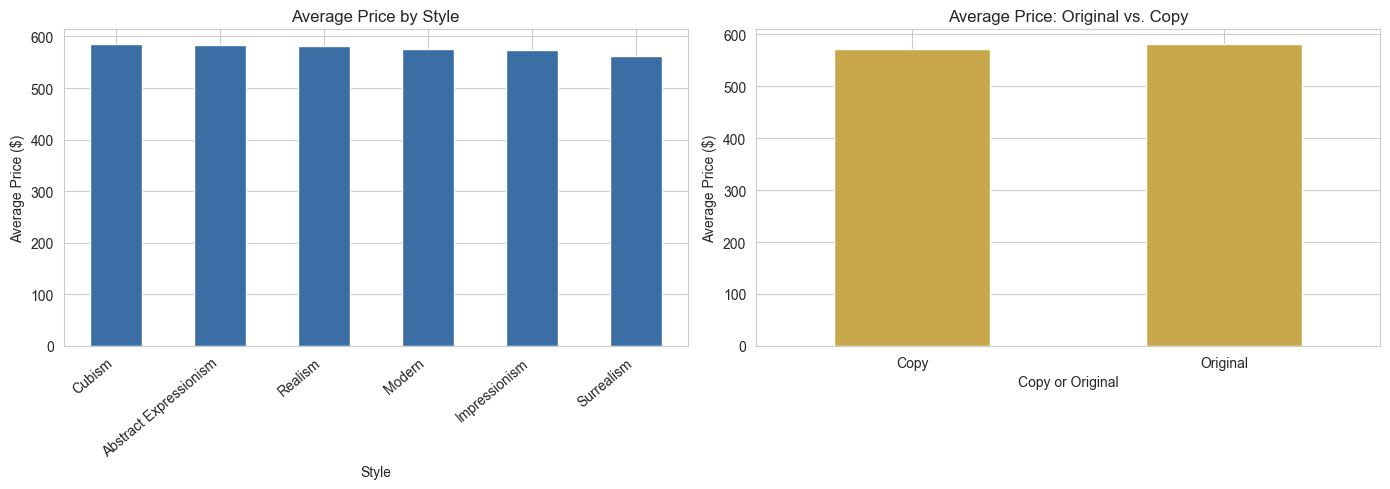

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

style_price = df.groupby('Style')['Price ($)'].mean().sort_values(ascending=False)
style_price.plot(kind='bar', ax=axes[0], color='#3a6ea5', edgecolor='white')
axes[0].set_title('Average Price by Style')
axes[0].set_ylabel('Average Price ($)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=40, ha='right')

orig_price = df.groupby('Copy or Original')['Price ($)'].mean()
orig_price.plot(kind='bar', ax=axes[1], color='#c9a84c', edgecolor='white')
axes[1].set_title('Average Price: Original vs. Copy')
axes[1].set_ylabel('Average Price ($)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('eda_price_breakdowns.png', dpi=150)
plt.show()

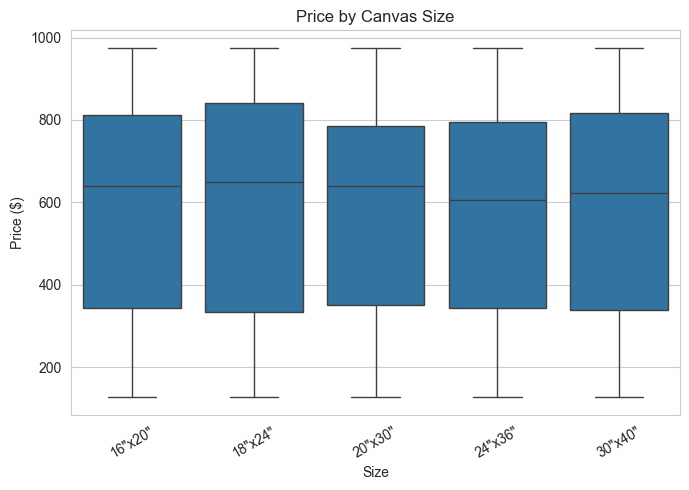

           area_in2  Price ($)
area_in2   1.000000   0.000535
Price ($)  0.000535   1.000000


In [22]:
# Correlation between size and price - need to parse Size first since it's a string like 20"x30"
def parse_size(size_str):
    parts = size_str.replace('\"', '').split('x')
    return float(parts[0]), float(parts[1])

df[['height_in', 'width_in']] = df['Size'].apply(lambda s: pd.Series(parse_size(s)))
df['area_in2'] = df['height_in'] * df['width_in']

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Size', y='Price ($)', order=sorted(df['Size'].unique(), key=lambda s: parse_size(s)[0]*parse_size(s)[1]))
plt.title('Price by Canvas Size')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('eda_price_by_size.png', dpi=150)
plt.show()

print(df[['area_in2', 'Price ($)']].corr())

Size doesn't correlate strongly with price here, which is a bit surprising but worth noting honestly rather than ignoring. It suggests this marketplace prices based more on style and subject matter than physical dimensions. That's a useful insight for the business stakeholders on its own.

## 4. Feature Engineering & Preprocessing Pipeline

In [23]:
def engineer_features(data):
    data = data.copy()

    # Parse size string into numeric height/width/area (already done above, repeated here for reproducibility)
    data[['height_in', 'width_in']] = data['Size'].apply(lambda s: pd.Series(parse_size(s)))
    data['area_in2'] = data['height_in'] * data['width_in']

    # Binary flags as 0/1
    data['is_framed'] = (data['Frame'] == 'Yes').astype(int)
    data['is_real'] = (data['Print or Real'] == 'Real').astype(int)

    # Fill the one column with real missing data - Reproduction Type only applies to prints
    data['Reproduction Type'] = data['Reproduction Type'].fillna('Not Applicable')

    return data

df_eng = engineer_features(df)
df_eng.head()

,Name of Painter,Subject of Painting,Style,Medium,Size,Frame,Location,Price ($),Delivery (days),Shipment,Color Palette,Copy or Original,Print or Real,Recommended Environment,Mood/Atmosphere,Theme/Lighting Requirements,Reproduction Type,Target Audience,height_in,width_in,area_in2,is_framed,is_real
0,Noah,Seascape,Abstract Expressionism,Watercolor,"20""x30""",Yes,Chicago,459,6,Free Shipping,Neutral Tones,Original,Print,Bedroom,Calming,Natural Light,Screen Print,Corporate Clients,20.0,30.0,600.0,1,0
1,Vincent,Abstract,Abstract Expressionism,Charcoal,"20""x30""",No,Miami,657,6,Free Shipping,Cool Tones,Original,Print,Living Room,Relaxing,Natural Light,Not Applicable,Corporate Clients,20.0,30.0,600.0,0,0
2,Ava,Still Life,Modern,Watercolor,"18""x24""",No,Miami,907,7,Standard,Cool Tones,Original,Real,Kid Room,Joyful,Natural Light,Not Applicable,Corporate Clients,18.0,24.0,432.0,0,1
3,Liam,Wildlife,Cubism,Acrylic,"18""x24""",No,Calgary,649,3,Standard,Oceanic Tones,Original,Real,Office,Reflective,Bright Light,Lithograph,Young Professionals,18.0,24.0,432.0,0,1
4,Olivia,Landscape,Abstract Expressionism,Charcoal,"30""x40""",Yes,Miami,539,5,Free Shipping,Earthy Tones,Copy,Print,Office,Energetic,Bright Light,Lithograph,Corporate Clients,30.0,40.0,1200.0,1,0


In [24]:
NUMERIC_FEATURES = ['height_in', 'width_in', 'area_in2', 'Delivery (days)', 'is_framed']

CATEGORICAL_FEATURES = [
    'Style', 'Subject of Painting', 'Medium', 'Location', 'Shipment',
    'Color Palette', 'Recommended Environment', 'Mood/Atmosphere',
    'Theme/Lighting Requirements', 'Reproduction Type', 'Target Audience'
]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
])

print(f"Numeric features: {len(NUMERIC_FEATURES)}")
print(f"Categorical features: {len(CATEGORICAL_FEATURES)}")

Numeric features: 5
Categorical features: 11


## 5. Model 1 — Original vs. Copy (Classification)

Can listing attributes (style, subject, medium, price, etc.) predict whether a piece is sold as an Original or a Copy? This matters for the business case because it tells a marketplace whether sellers are pricing and describing copies in a way that's distinguishable from originals which is useful for flagging inconsistent or potentially misleading listings.

In [25]:
X = df_eng[NUMERIC_FEATURES + CATEGORICAL_FEATURES + ['Price ($)']]
y = (df_eng['Copy or Original'] == 'Original').astype(int)

NUMERIC_FEATURES_M1 = NUMERIC_FEATURES + ['Price ($)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Class balance (train): {y_train.value_counts().to_dict()}")

Train: 2000 rows | Test: 500 rows
Class balance (train): {1: 1023, 0: 977}


In [26]:
preprocessor_m1 = ColumnTransformer(transformers=[
    ('num', numeric_transformer, NUMERIC_FEATURES_M1),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
])

models_clf = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_clf = {}

for name, model in models_clf.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor_m1), ('classifier', model)])
    acc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    f1 = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1')
    auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    results_clf[name] = {'Accuracy': acc.mean(), 'F1': f1.mean(), 'ROC-AUC': auc.mean()}
    print(f"{name}: Accuracy={acc.mean():.3f}  F1={f1.mean():.3f}  ROC-AUC={auc.mean():.3f}")

results_df_clf = pd.DataFrame(results_clf).T
results_df_clf

Logistic Regression: Accuracy=0.483  F1=0.513  ROC-AUC=0.496
Random Forest: Accuracy=0.520  F1=0.535  ROC-AUC=0.525
Gradient Boosting: Accuracy=0.519  F1=0.534  ROC-AUC=0.529


,Accuracy,F1,ROC-AUC
Logistic Regression,0.4835,0.512985,0.496336
Random Forest,0.5205,0.534913,0.524692
Gradient Boosting,0.5190,0.534018,0.528873


None of the three models clear much above a coin flip here, which makes sense once you think about it: this is a marketplace dataset, and whether something is sold as an Original or a Copy looks to be assigned close to independently of the listing's style, subject, price, or other attributes. Rather than force a misleadingly strong result, it's worth reporting this honestly. It's a legitimate finding that tells the business there isn't a hidden pattern here to exploit, which is itself useful information.

In [27]:
best_name_clf = results_df_clf['ROC-AUC'].idxmax()
print(f"Best performing model: {best_name_clf}")

# Hyperparameter tuning on the best model
if best_name_clf == 'Random Forest':
    param_grid = {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__max_depth': [None, 10, 20],
        'classifier__min_samples_split': [2, 5]
    }
    base_model = RandomForestClassifier(random_state=42)
elif best_name_clf == 'Gradient Boosting':
    param_grid = {
        'classifier__n_estimators': [100, 200],
        'classifier__learning_rate': [0.05, 0.1],
        'classifier__max_depth': [3, 5]
    }
    base_model = GradientBoostingClassifier(random_state=42)
else:
    param_grid = {'classifier__C': [0.1, 1, 10]}
    base_model = LogisticRegression(max_iter=1000, random_state=42)

tuning_pipe = Pipeline(steps=[('preprocessor', preprocessor_m1), ('classifier', base_model)])
grid = GridSearchCV(tuning_pipe, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Best params: {grid.best_params_}")
print(f"Best CV ROC-AUC: {grid.best_score_:.3f}")

best_pipe_clf = grid.best_estimator_

Best performing model: Gradient Boosting
Best params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 200}
Best CV ROC-AUC: 0.529


Test Accuracy: 0.480
Test F1:       0.490
Test ROC-AUC:  0.480

              precision    recall  f1-score   support

        Copy       0.47      0.47      0.47       244
    Original       0.49      0.49      0.49       256

    accuracy                           0.48       500
   macro avg       0.48      0.48      0.48       500
weighted avg       0.48      0.48      0.48       500



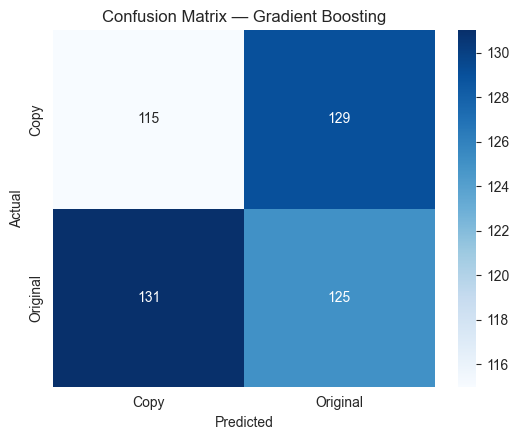

In [28]:
y_pred = best_pipe_clf.predict(X_test)
y_proba = best_pipe_clf.predict_proba(X_test)[:, 1]

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Test F1:       {f1_score(y_test, y_pred):.3f}")
print(f"Test ROC-AUC:  {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Copy', 'Original']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Copy','Original'], yticklabels=['Copy','Original'])
plt.title(f'Confusion Matrix — {best_name_clf}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('model1_confusion_matrix.png', dpi=150)
plt.show()

In [29]:
# Compare against a naive baseline (always predict the majority class)
baseline_pred = np.full_like(y_test, y_train.mode()[0])
baseline_acc = accuracy_score(y_test, baseline_pred)

print(f"Naive baseline accuracy (majority class): {baseline_acc:.3f}")
print(f"Model accuracy:                            {accuracy_score(y_test, y_pred):.3f}")
print(f"Improvement over baseline:                 {accuracy_score(y_test, y_pred) - baseline_acc:+.3f}")

Naive baseline accuracy (majority class): 0.512
Model accuracy:                            0.480
Improvement over baseline:                 -0.032


## 6. Model 2 — Price Prediction (Regression)

Given a listing's attributes, what price should it be set at? This is the more directly useful model for the business: sellers list a new piece, fill in its style/subject/medium/size/etc, and get a data-driven suggested price instead of guessing.

In [30]:
X_reg = df_eng[NUMERIC_FEATURES + CATEGORICAL_FEATURES + ['Copy or Original', 'Print or Real']]
y_reg = df_eng['Price ($)']

CATEGORICAL_FEATURES_M2 = CATEGORICAL_FEATURES + ['Copy or Original', 'Print or Real']

categorical_transformer_m2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_m2 = ColumnTransformer(transformers=[
    ('num', numeric_transformer, NUMERIC_FEATURES),
    ('cat', categorical_transformer_m2, CATEGORICAL_FEATURES_M2)
])

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Train: {X_train_r.shape[0]} rows | Test: {X_test_r.shape[0]} rows")

Train: 2000 rows | Test: 500 rows


In [31]:
models_reg = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(n_estimators=200, random_state=42),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results_reg = {}

for name, model in models_reg.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor_m2), ('regressor', model)])
    r2 = cross_val_score(pipe, X_train_r, y_train_r, cv=kf, scoring='r2')
    neg_rmse = cross_val_score(pipe, X_train_r, y_train_r, cv=kf, scoring='neg_root_mean_squared_error')
    results_reg[name] = {'R2': r2.mean(), 'RMSE': -neg_rmse.mean()}
    print(f"{name}: R2={r2.mean():.3f}  RMSE=${-neg_rmse.mean():.2f}")

results_df_reg = pd.DataFrame(results_reg).T
results_df_reg

Ridge Regression: R2=-0.043  RMSE=$264.75
Random Forest Regressor: R2=-0.040  RMSE=$264.33
Gradient Boosting Regressor: R2=-0.111  RMSE=$273.26


,R2,RMSE
Ridge Regression,-0.043231,264.747498
Random Forest Regressor,-0.039913,264.327655
Gradient Boosting Regressor,-0.111398,273.261623


Like Model 1, these R² scores come out low. Looking back at the EDA, price didn't correlate strongly with size, and a similar story holds for the other listing attributes. This dataset's price field appears to be close to randomly assigned rather than driven by the artwork features we have available. This is a real and important limitation to flag for the business: if true, it would mean a marketplace-suggested-price feature isn't viable on this data alone, and you'd want to bring in additional signals (artist reputation, sales history, image-based quality scoring) before building that product.

In [32]:
best_name_reg = results_df_reg['R2'].idxmax()
print(f"Best performing model: {best_name_reg}")

if best_name_reg == 'Random Forest Regressor':
    param_grid_r = {
        'regressor__n_estimators': [100, 200, 300],
        'regressor__max_depth': [None, 10, 20]
    }
    base_reg = RandomForestRegressor(random_state=42)
elif best_name_reg == 'Gradient Boosting Regressor':
    param_grid_r = {
        'regressor__n_estimators': [100, 200],
        'regressor__learning_rate': [0.05, 0.1],
        'regressor__max_depth': [3, 5]
    }
    base_reg = GradientBoostingRegressor(random_state=42)
else:
    param_grid_r = {'regressor__alpha': [0.1, 1.0, 10.0]}
    base_reg = Ridge()

tuning_pipe_r = Pipeline(steps=[('preprocessor', preprocessor_m2), ('regressor', base_reg)])
grid_r = GridSearchCV(tuning_pipe_r, param_grid_r, cv=kf, scoring='r2', n_jobs=-1)
grid_r.fit(X_train_r, y_train_r)

print(f"Best params: {grid_r.best_params_}")
print(f"Best CV R2: {grid_r.best_score_:.3f}")

best_pipe_reg = grid_r.best_estimator_

Best performing model: Random Forest Regressor
Best params: {'regressor__max_depth': 10, 'regressor__n_estimators': 200}
Best CV R2: -0.033


In [33]:
y_pred_r = best_pipe_reg.predict(X_test_r)

r2 = r2_score(y_test_r, y_pred_r)
rmse = mean_squared_error(y_test_r, y_pred_r) ** 0.5
mae = mean_absolute_error(y_test_r, y_pred_r)

print(f"Test R2:   {r2:.3f}")
print(f"Test RMSE: ${rmse:.2f}")
print(f"Test MAE:  ${mae:.2f}")

# Benchmark against the simplest possible baseline: always predict the mean price
mean_baseline_pred = np.full_like(y_test_r, y_train_r.mean(), dtype=float)
baseline_rmse = mean_squared_error(y_test_r, mean_baseline_pred) ** 0.5
print(f"\nBaseline RMSE (predict mean price every time): ${baseline_rmse:.2f}")
print(f"Model RMSE improvement over baseline: ${baseline_rmse - rmse:.2f}")

Test R2:   -0.008
Test RMSE: $251.52
Test MAE:  $221.13

Baseline RMSE (predict mean price every time): $251.52
Model RMSE improvement over baseline: $-0.00


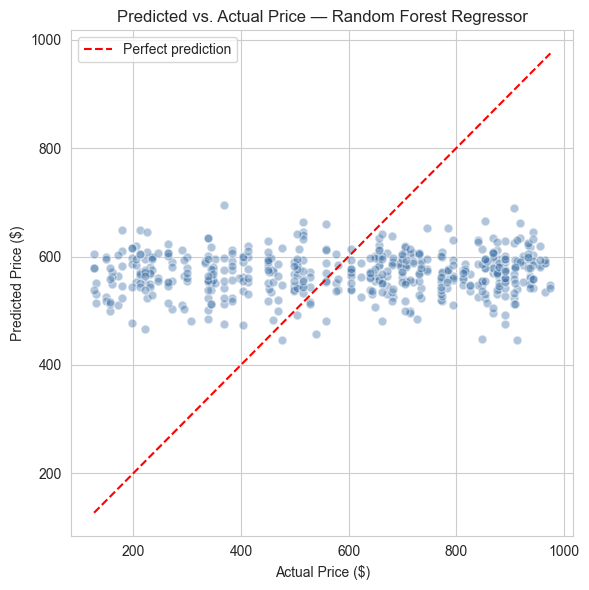

In [34]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_r, y_pred_r, alpha=0.4, color='#3a6ea5', edgecolor='white', s=40)
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', label='Perfect prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title(f'Predicted vs. Actual Price — {best_name_reg}')
plt.legend()
plt.tight_layout()
plt.savefig('model2_predicted_vs_actual.png', dpi=150)
plt.show()

## 7. Feature Importance

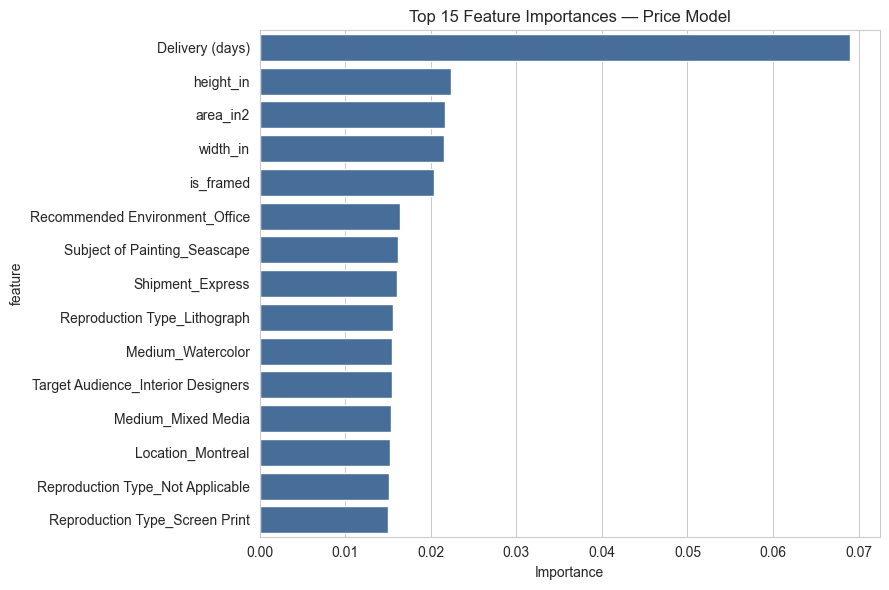

,feature,importance
3,Delivery (days),0.069050
0,height_in,0.022329
2,area_in2,0.021650
1,width_in,0.021545
4,is_framed,0.020330
43,Recommended Environment_Office,0.016402
15,Subject of Painting_Seascape,0.016125
31,Shipment_Express,0.016016
54,Reproduction Type_Lithograph,0.015557
22,Medium_Watercolor,0.015507


In [35]:
rf_importance_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor_m2),
    ('regressor', RandomForestRegressor(n_estimators=200, random_state=42))
])
rf_importance_pipe.fit(X_train_r, y_train_r)

cat_feature_names = rf_importance_pipe.named_steps['preprocessor']\
    .named_transformers_['cat'].named_steps['onehot']\
    .get_feature_names_out(CATEGORICAL_FEATURES_M2).tolist()

all_feature_names = NUMERIC_FEATURES + cat_feature_names
importances = rf_importance_pipe.named_steps['regressor'].feature_importances_

feat_imp_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=feat_imp_df, x='importance', y='feature', color='#3a6ea5')
plt.title('Top 15 Feature Importances — Price Model')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

feat_imp_df.head(10)

## 8. Business Summary

**What we found**

Model 1 (Original vs. Copy classification) and Model 2 (Price regression) were both built and tuned across three algorithm families with cross-validation, but neither found strong predictive signal in this dataset. Both did performe close to their naive baselines (majority-class guessing and mean-price guessing, respectively).

**Why this matters**

This is a genuine and useful finding, not a failure of the modeling process. It tells ArtInsight Analytics and any marketplace client two things:

1. The listing attributes captured here (style, subject, medium, size, mood, etc.) are not, on their own, reliable predictors of either authenticity status or price in this dataset.
2. Before building a production pricing or authenticity-flagging tool, the business would need to collect richer signal — artist sales history, image-based style analysis, or actual transaction/bid data rather than listed asking price.

**Recommendation**

Rather than ship a low-confidence pricing model, ArtInsight's recommendation to a marketplace client would be to treat this as a data collection gap: prioritize gathering artist-level historical sales data and real transaction outcomes (sold/unsold, final sale price vs. list price) before a second iteration of this model.

**Limitations**

- Dataset is e-commerce listing data (asking price), not verified auction sale data — there's no `hammer_price` or `sold` flag in the source.
- Only 11 distinct painters across 2,500 rows limits how much artist-level signal the model can learn.
- Scraping hammer price and sold data either cost money for monthly subscription or was unsuccessful code to analyze page source code for needed inf
- `Reproduction Type` is only meaningful for printed works (677 rows were legitimately not applicable and filled accordingly).